# Data

In [1]:
!ls

am_download_data
am_runtime
am_runtime_nns
am_viewers
games-all.json
games_shooter
log.local.bin.old
log.local.logtime2.bin
log.txt.old
proof-of-concept.ipynb
proof-of-concept-open-data-round1.ipynb
proof-of-concept-round2-backup-1.ipynb
proof-of-concept-round2.ipynb
proof-of-concept-round3-backup1.ipynb
proof-of-concept-round3-backup2.ipynb
proof-of-concept-round3-backup3.ipynb
proof-of-concept-round3.ipynb
proof-of-concept-round3-parallel2.ipynb
proof-of-concept-round3-parallel.ipynb
proof-of-concept-round4.ipynb
proof-of-concept-round5.ipynb
proof-of-concept-round6.ipynb
req.json
shoot-prod.sh
shoot.sh
stand
t.t
Untitled1.ipynb
Untitled.ipynb
yugioh


In [115]:
!ls yugioh

ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl


In [238]:
import pickle
import numpy as np

from importlib import reload 

In [239]:
import matrix_approx_zeshel

matrix_approx_zeshel = reload(matrix_approx_zeshel)

!ls  | grep matrix_approx_zeshel

matrix_approx_zeshel.py


In [140]:
yugioh = list()

with open("yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl", "rb") as f:
    yugioh.append(
        pickle.load(f)
    )
    
with open("yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl", "rb") as f:
    yugioh.append(
        pickle.load(f)
    )
    
with open("yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl", "rb") as f:
    yugioh.append(
        pickle.load(f)
    )
    
with open("yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl", "rb") as f:
    yugioh.append(
        pickle.load(f)
    )
    
for i in range(len(yugioh) - 1):
    assert (
        yugioh[i]["arg_dict"]["n_ment_start"]
        + yugioh[i]["arg_dict"]["n_ment"]
        == yugioh[i + 1]["arg_dict"]["n_ment_start"] 
    )
    
yugioh_relevs = list(map(lambda x: x["ment_to_ent_scores"], yugioh))
yugioh_relevs = np.vstack(yugioh_relevs)
yugioh_relevs.shape

(2000, 10031)

In [191]:
yugioh[0]["test_data"][

{'label_id': 3079,
 'context_left': 'katsuya jonouchi ( manga ) katsuya jonouchi ( " jōnouchi katsuya " ) , known as joey wheeler in the english version of " yu - gi - oh ! the dark side of dimensions " , is a character in the " yu - gi - oh ! " manga . this is the original depiction of katsuya jonouchi , known as joey wheeler in most english media , as created by kazuki takahashi . jonouchi is the best friend of yugi mutou and hiroto honda . he suffered a poor upbringing with his parents divorcing and him living with his alcoholic father , while his sister shizuka lived with their mother . jonouchi used to be a thug and even hung out with hirutani \' s gang for a while . after becoming friends with yugi he became more righteous and would do anything to protect his friends or innocent people being taken advantage of . jonouchi starts out as a weak player after taking - up " duel monsters " , but becomes more powerful as he learns from yugi and dark yugi and fights to protect people he 

In [143]:
class EvalContextRelevs:
    def __init__(self, relevs, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
        self.relevs = np.array(relevs)
        self.reqs_count = self.relevs.shape[0]
        self.games_count = self.relevs.shape[1]
        
        self.key_games = (
            np.random.choice(np.arange(self.games_count), key_size, replace=False)
            if key_games is None else
            key_games
        )
        np.random.seed(seed)
        #np.random.shuffle(self.requests)

        self.try_det_attempts(det_attempts)
        self.train_split = int(self.reqs_count * train_size)

        assert key_size + 1 < self.train_split

        self.key_relevs = self.relevs[:key_size]
        self.train_relevs = self.relevs[key_size + 1: self.train_split]
        self.test_relevs = self.relevs [self.train_split:]

        self.slices = ["key", "train", "test"]
        print(len(self.key_relevs), len(self.train_relevs), len(self.test_relevs))

    def get_top_games(self):
        return self.relevs.mean(axis=0).argsort()[:100].numpy()

    def set_top_games_as_key(self):
        self.key_games = self.get_top_games()
        return self

    def try_det_attempts(self, det_attempts, model_id = 6):
        pass

    def get_relevs(self, t = "train"):
        if t == "train":
            return self.train_relevs
        elif t == "key":
            return self.key_relevs
        elif t == "test":
            return self.test_relevs
        else:
            assert False
            
    def get_requests(self, t = "train"):
        if t == "train":
            return self.train_reqs
        elif t == "key":
            return self.key_reqs
        elif t == "test":
            return self.test_reqs
        else:
            assert False

In [144]:
ctx = EvalContextRelevs(yugioh_relevs)

100 1299 600


In [145]:
ctx.slices

['key', 'train', 'test']

In [146]:
class Popular:
    def __init__(self, ctx):
        self.ctx = ctx
        self.game_avg_scores = {
            t : self.get_user_scores(t).mean(axis = 0)
            for t in self.ctx.slices
        }
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        return [self.top_logits for _ in self.get_user_scores(t)]
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

### Меньше - лучше?

In [147]:
m = Popular(ctx)

In [148]:
m.fit()
m.get_score("test"), m.get_score("train")

np.mean(results), mse, len(results) =  0.08773333333333333 0.65377665 600
np.mean(results), mse, len(results) =  0.08711316397228638 0.6827519 1299


(0.08773333333333333, 0.08711316397228638)

In [173]:
import tensorflow as tf
import copy
import tensorflow_ranking as tfr

DEFAULT_FIT_KWARGS = {
    "learning_rate": 0.001,
    "n": 500,
    "c": 5000,
    "train_popbias": False,
    "train_bias": False,
    "train_vbias": False,
    "verbose": True,
    "train_matrix": True,
    "train_dssm": False,
    "loss": "mse",
    "ubatch": 1e9,
}

class CBKnnV0(Popular):
    def __init__(self, ctx, fit_kwargs = dict()):
        super().__init__(ctx)
        
        self.fit_kwargs = fit_kwargs
        
        self.embed_users = {
            t : np.array([
                    np.array([r_i[i] for i in ctx.key_games])
                    for r_i in ctx.get_relevs(t)
                ])
            for t in ctx.slices
        }
        self.embed_users_mean = {
            t : self.embed_users[t].mean(axis = 0)
            for t in ctx.slices
        }
        # embed_users = embed_users - embed_users_mean
        print("self.embed_users['train'].shape = ", self.embed_users['train'].shape )
        
        self.embed_games = np.array([
            np.array([r[g_i] for r in ctx.get_relevs("key")])
            for g_i in range(ctx.games_count)
        ])
        
        self.embed_games_mean = self.embed_games.mean(axis = 0)
        
        # embed_games = embed_games - embed_games_mean
        print("self.embed_games.shape = ", self.embed_games.shape)
        
        self.games_top_key = self.embed_games.mean(axis = 1)
        
        self.games2users = np.array([
            self.embed_games[g_i]
            for g_i in ctx.key_games
        ])
        print("self.games2users.shape = ", self.games2users.shape)
        
        self.core_users_scores = ctx.get_relevs("key")
        print("self.core_users_scores.shape = ", self.core_users_scores.shape)
        
        self.core_users_embs = self.embed_users["key"]
        print("self.core_users_embs.shape = ", self.core_users_embs.shape)
        
        self.ge_users = (
            (self.embed_users["train"].T / self.embed_users["train"].mean(axis=1)).T @ self.games2users
        )
        # ge_users = embed_users @ games2users
        print("self.ge_users.shape = ", self.ge_users.shape)
    
    def __repr__(self):
        return "CbKnn(" + str(self.fit_kwargs) + ")"
        
    # inherited   
    # def get_user_scores(self, t):
    
    def get_user_embs(self, t):
        return (self.embed_users[t] - self.embed_users_mean["train"]) / self.embed_users[t].std(axis=0)
        # return self.embed_users[t]
    
    def get_game_embs(self):
        return (self.embed_games - self.embed_games.mean(axis=0)) / self.embed_games.std(axis=0)
        #return self.embed_games

    def fit(self, **kwargs):
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        p.update(kwargs)

        self.train_bias = p["train_bias"]
        self.train_vbias = p["train_vbias"]
        self.train_popbias = p["train_popbias"]
        self.train_matrix = p["train_matrix"]
        self.train_dssm = p["train_dssm"]
        self.loss = p["loss"]

        train_user_scores = self.get_user_scores("train")
        train_user_embs = self.get_user_embs("train")
        game_embs = self.get_game_embs()
        
        initializer = tf.keras.initializers.GlorotUniform()
        values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
        self.W = tf.Variable(values / 100., trainable = True) 
        self.pb = tf.Variable(1., trainable = True) 
        self.b = tf.Variable(0., trainable = True) 
        
        if p["verbose"]:
            print("self.W = ", self.W)
            print("0-loss = ", tf.reduce_mean((train_user_scores - 0) ** 2))
    
        opt =  tf.keras.optimizers.Adam(learning_rate=p["learning_rate"])

        if self.train_dssm:
            self.train_dssm = True

            dim = game_embs.shape[1]
            self.g_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation='relu'),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.g_dssm(game_embs)
            
            # dim = train_user_embs.shape[1]
            self.u_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation='relu'),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.u_dssm(train_user_embs)
            
        if self.train_vbias:
            self.vb = tf.Variable(
                np.zeros_like(self.game_avg_scores["train"], dtype=np.float32),
                trainable = True
            ) 
        
        
        for i in range(p["n"]):
            def loss():
                def get_logits_scores(loss_batch = 1e9):
                    game_slice = None
                    
                    ubatch = p["ubatch"]
                    if ubatch >= train_user_scores.shape[0]:
                        train_user_embs_ = train_user_embs
                        scores_ = train_user_scores
                    else:
                        u_slice = np.random.choice(np.arange(train_user_scores.shape[0]), ubatch, replace = True)
                        train_user_embs_ = train_user_embs[u_slice]
                        scores_ = train_user_scores[u_slice]
                    
                    if loss_batch >= game_embs.shape[0]:
                        game_embs_ = game_embs
                        scores_ = scores_
                    else:
                        game_slice = np.random.choice(np.arange(game_embs.shape[0]), loss_batch, replace = True)
                        game_embs_ = game_embs[game_slice]
                        scores_ = scores_[:, game_slice]
                        
                    
                    logits = 0
                    
                    if self.train_matrix:
                        logits += train_user_embs_ @ self.W @ game_embs_.T

                    if self.train_dssm:
                        logits += self.u_dssm(train_user_embs_) @ tf.transpose(self.g_dssm(game_embs_))
                    
                    if self.train_popbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.pb * self.game_avg_scores["train"]
                        else:
                            logits += self.pb * self.game_avg_scores["train"][game_slice]
                        
                    if self.train_vbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.vb
                        else:
                            logits += tf.gather(self.vb, game_slice)
                        
                    if self.train_bias:
                        logits += self.b
                        
                    return logits, scores_
                        
                if self.loss == "mse":
                    logits, scores = get_logits_scores()
                    v = tf.reduce_mean((scores - logits) ** 2)
                elif self.loss == "qmse":
                    logits, scores = get_logits_scores()
                    q_mean = scores.mean(axis=1)
                    v = tf.reduce_mean(((scores.T - q_mean).T - logits) ** 2)
                elif self.loss == "ApproxNDCGLoss":
                    while True:
                        logits, scores = get_logits_scores(
                            loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))

                        v = tfr.keras.losses.ApproxNDCGLoss()(
                            scores.astype(np.float32),
                            logits
                        )
                    
                        if not tf.math.is_nan(v).numpy().any():
                            break
                        else:
                            if p["verbose"]:
                                print("nanloss ignored")
                elif self.loss == "softmax":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ))
                elif self.loss == "softmax_weighted":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ) * scores)
                elif self.loss == "sigmoid_top_100":
                    logits, scores = get_logits_scores()
                    mask = np.argsort(-scores, axis=1) < 100
                    v = -tf.reduce_mean(
                        tf.math.log_sigmoid((2 * mask - 1) * logits)
                    )
                else:
                    assert False
                    
                v += tf.reduce_mean(self.W * self.W) * p["c"]
                
                if p["verbose"]:
                    print(v.numpy())
                
                return v

            weights = list()
            
            if self.train_matrix:
                weights += [self.W]

            if self.train_dssm:
                weights += self.u_dssm.weights
                weights += self.g_dssm.weights
            
            if self.train_popbias:
                weights += [self.pb]

            if self.train_vbias:
                weights += [self.vb]   
                
            if self.train_bias:
                weights += [self.b]   
                
                
            opt.minimize(loss, weights)
        print("last loss = ", loss())

    def recommend(self, t):
        logits = 0
                    
        if self.train_matrix:
            logits += self.get_user_embs(t) @ self.W @ self.get_game_embs().T

        if self.train_dssm:
            logits += self.u_dssm(self.get_user_embs(t)) @ tf.transpose(self.g_dssm(self.get_game_embs()))

        if self.train_popbias:
            logits += self.pb * self.game_avg_scores["train"]       
            
        if self.train_vbias:
            logits += self.vb
            
        if self.train_bias:
            logits += self.b
            
        return logits
    
    # inherited
    # def get_score(self, t, topsize = 100):
    
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [174]:
N = 3000

In [182]:
m = Popular(ctx)
m.fit()
m.get_score("test"), m.get_score("train")

np.mean(results), mse, len(results) =  0.08773333333333333 0.65377665 600
np.mean(results), mse, len(results) =  0.08711316397228638 0.6827519 1299


(0.08773333333333333, 0.08711316397228638)

In [176]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("test"), m.get_score("train")

self.embed_users['train'].shape =  (1299, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1299, 100)
last loss =  tf.Tensor(-0.0046343706, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.40851666666666664 1850.3907 600
np.mean(results), mse, len(results) =  0.4747421093148576 1820.2621 1299


(0.40851666666666664, 0.4747421093148576)

In [175]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("test"), m.get_score("train")

self.embed_users['train'].shape =  (1299, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1299, 100)
last loss =  tf.Tensor(-0.004744081, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.42643333333333333 1014.6691 600
np.mean(results), mse, len(results) =  0.49946112394149345 1014.13336 1299


(0.42643333333333333, 0.49946112394149345)

In [177]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("test"), m.get_score("train")

self.embed_users['train'].shape =  (1299, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1299, 100)
last loss =  tf.Tensor(-0.0041868095, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.40581666666666666 310.591 600
np.mean(results), mse, len(results) =  0.445080831408776 310.87872 1299


(0.40581666666666666, 0.445080831408776)

In [178]:
N = 5000

In [179]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("test"), m.get_score("train")

self.embed_users['train'].shape =  (1299, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1299, 100)
last loss =  tf.Tensor(-0.004716801, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4108833333333333 3513.8074 600
np.mean(results), mse, len(results) =  0.4891916859122402 3512.724 1299


(0.4108833333333333, 0.4891916859122402)

In [180]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("test"), m.get_score("train")

self.embed_users['train'].shape =  (1299, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1299, 100)
last loss =  tf.Tensor(-0.0052873986, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4267666666666667 1779.3512 600
np.mean(results), mse, len(results) =  0.5154965357967668 1795.5594 1299


(0.4267666666666667, 0.5154965357967668)

In [181]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("test"), m.get_score("train")

self.embed_users['train'].shape =  (1299, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1299, 100)
last loss =  tf.Tensor(-0.0041336715, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.40995 728.39056 600
np.mean(results), mse, len(results) =  0.4538491147036181 729.3683 1299


(0.40995, 0.4538491147036181)

In [178]:
N = 5000

In [179]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("test"), m.get_score("train")

self.embed_users['train'].shape =  (1299, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1299, 100)
last loss =  tf.Tensor(-0.004716801, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4108833333333333 3513.8074 600
np.mean(results), mse, len(results) =  0.4891916859122402 3512.724 1299


(0.4108833333333333, 0.4891916859122402)

In [180]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("test"), m.get_score("train")

self.embed_users['train'].shape =  (1299, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1299, 100)
last loss =  tf.Tensor(-0.0052873986, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4267666666666667 1779.3512 600
np.mean(results), mse, len(results) =  0.5154965357967668 1795.5594 1299


(0.4267666666666667, 0.5154965357967668)

In [181]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("test"), m.get_score("train")

self.embed_users['train'].shape =  (1299, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1299, 100)
last loss =  tf.Tensor(-0.0041336715, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.40995 728.39056 600
np.mean(results), mse, len(results) =  0.4538491147036181 729.3683 1299


(0.40995, 0.4538491147036181)

In [267]:
import torch

In [268]:
class AnnCUR(Popular):
    def __init__(self, ctx, fit_kwargs=dict()):
        super().__init__(ctx)
        self.fit_kwargs = fit_kwargs
        
        self.key_cols_idx = np.array(sorted(ctx.key_games))
        rows_idx = np.arange(ctx.get_relevs("train").shape[0])

        self.cur = matrix_approx_zeshel.CURApprox(
            rows=torch.from_numpy(ctx.get_relevs("train")),
            cols=torch.from_numpy(ctx.get_relevs("train")[:, self.key_cols_idx]),
            row_idxs=rows_idx,
            col_idxs=self.key_cols_idx,
            approx_preference="rows"
        )
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        key_relevs = torch.from_numpy(ctx.get_relevs(t)[:, self.key_cols_idx])
        return self.cur.get_complete_row(key_relevs)
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

In [269]:
m = AnnCUR(ctx)

In [270]:
m.fit()

In [271]:
m.get_score("test")

np.mean(results), mse, len(results) =  0.4505333333333334 0.21238025 600


0.4505333333333334

In [1]:
import collections
import pickle
import numpy as np
import tqdm
import os
import gc

import matplotlib.pyplot as plt


def load(limit, raw_path = "stand/log.local.logtime2.txt", path = "log.local.logtime2.bin", key_games = None, seed = 17, det_attempts = 0):
    readvector = lambda s : np.array(list(map(float, s.strip()[1:-2].split(","))))
    requests = list()
    docembs = collections.defaultdict(dict)

    if os.path.isfile(path):
        with open(path, "rb") as f:
            flimit, frequests, fdocembs = pickle.load(f)
            if flimit == limit:
                requests, docembs = frequests, fdocembs
            else:
                print(f"WARN: buffered limit is different, {flimit} != {limit}, reloading...")

    if not requests:
        with open(raw_path) as f:
            req = list()
            reqid = None
            models = list()
            prevreqmodel = None
            reqmodel = dict()
            prevmodelid = -1
            bannermodelid = -1
            for i, line in tqdm.tqdm_notebook(enumerate(f)):
                if line.startswith("Model = 6;"):
                    prevreqmodel = reqmodel
                    reqmodel = dict()

                if line.startswith("Model = "):
                    spl = line.split(" ")
                    prevmodelid = int(spl[2][:-1])
                    bannermodelid = max(bannermodelid , prevmodelid)
                    reqmodel[prevmodelid] = readvector(spl[3])
                elif line.startswith("dbid"):
                    spl = line.split(" ")
                    dbid = int(spl[1][:-1])
                    docembs[bannermodelid][dbid] = readvector(spl[2])
                elif line.startswith("seed"):
                    if len(requests) >= limit:
                        break
                    if req:
                        requests.append((reqid, prevreqmodel, sorted(req)))
                        req = list()
                    reqid = "$_" + (line.split()[1] + "_" + line.split()[3])
                else:
                    req.append(
                        (int(line.split()[0]), float(line.split()[1]))
                    )
        
        with open(path, "wb") as f:
            pickle.dump((limit, requests, docembs), f)

    games_count = len(requests[0][2])
    assert games_count == 16514
    requests = [r for r in requests if len(r[2]) == games_count]
    
    print([(i, len(docembs[i].keys())) for i in docembs])  # should be equal
    docblocks = {
        mid : np.array([x[1] for x in sorted(list(docembs[mid].items()))])
        for mid in docembs
    }
    
    class EvalContext:
        def __init__(self, games_count = games_count, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
            self.games_count = games_count
            self.key_games = (
                np.random.choice(np.arange(games_count), key_size, replace=False)
                if key_games is None else
                key_games
            )

            self.requests = requests
            np.random.seed(seed)
            np.random.shuffle(self.requests)
            
            self.try_det_attempts(det_attempts)

            self.key_reqs = self.requests[:key_size + 1]
            self.key_reqs_idx = np.arange(key_size + 1)

            self.train_split = int(len(self.requests) * train_size)

            assert key_size + 1 < self.train_split

            self.train_reqs = self.requests[key_size + 1: self.train_split]
            self.test_reqs = self.requests[self.train_split:]

            self.slices = ["key", "train", "test"]
            print(len(self.key_reqs), len(self.train_reqs), len(self.test_reqs))

            self.docblocks = docblocks
            
        def get_top_games(self):
            if not hasattr(self, "top_games"):
                embed_games = np.array([
                    np.array([r[2][g_i][1] for r in self.get_requests("train")])
                    for g_i in range(self.games_count)
                ])

                self.embed_games_mean = embed_games.mean(axis=1)
                self.top_games_all = (-self.embed_games_mean).argsort()
                self.top_games = self.top_games_all[:len(self.key_games)]

            return self.top_games
        
        def set_top_games_as_key(self):
            self.key_games = self.get_top_games()
            return self
        
        def try_det_attempts(self, det_attempts, model_id = 6):
            def get_det(r, r_i_array):
                kr = np.array([
                    r[r_i][1][model_id]
                    for r_i in r_i_array[:100]
                ])
                return np.abs(np.linalg.det(kr[:kr.shape[1], :]))

            best_i_array = np.arange(len(self.requests))

            for _ in range(det_attempts):
                # print("try update key_reqs...")
                
                r_i_array = np.arange(len(self.requests))
                np.random.shuffle(r_i_array)
                
                n, o = get_det(self.requests, r_i_array), get_det(self.requests, best_i_array)
                # print(n, o)
                if n > o:
                    best_i_array = r_i_array
                    # print("updated!")

            print("Best det = ", get_det(self.requests, best_i_array))
            
            new_requests = [
                self.requests[i]
                for i in best_i_array
            ]
            
            del self.requests
            gc.collect()

            self.requests = new_requests
            print(get_det(self.requests, np.arange(len(self.requests))))

        def get_requests(self, t = "train"):
            if t == "train":
                return self.train_reqs
            elif t == "key":
                return self.key_reqs
            elif t == "test":
                return self.test_reqs
            else:
                assert False

    return EvalContext(key_games = key_games, seed = seed, det_attempts = det_attempts)

# Custom preparations

In [2]:
import json

def get_cat_top(ctx, games_all_json = "games-all.json", max_per_category = 4):
    with open(games_all_json) as f:
        games_all = json.loads(f.read())

    game2category = {
        g_i["appID"] : g_i["categoryName"]["categories"]
        for g_i in games_all
    }


    flat_game_id_2_app_id = {i: row[0] for i, row in enumerate(ctx.requests[0][2])}

    all_category = set()
    for i, c in game2category.items():
        for c_i in c:
            all_category.add(c_i)

    def get_cat(top_games):
        flat_game_id_2_app_id = {i: row[0] for i, row in enumerate(ctx.requests[0][2])}
        top_cat = set()
        for g_i in top_games:
            app_id = flat_game_id_2_app_id[g_i]
            if app_id in game2category:
                for c_i in game2category[app_id]:
                    top_cat.add(c_i)
            else:
                # print("nf")
                pass
        return top_cat

    cat_top = list()
    cobs = collections.defaultdict(int)

    top_games = ctx.get_top_games()

    for g_i in ctx.top_games_all:
        app_id = flat_game_id_2_app_id[g_i]
        categories = tuple(sorted(game2category[app_id] if app_id in game2category else []))

        skip = False
        for cs_i in categories:
            if cobs[cs_i] >= max_per_category:
                skip = True
                break

        if skip:
            continue

        for cs_i in categories:
            cobs[cs_i] += 1

        cat_top.append(g_i)
        if len(cat_top) == len(top_games):
            break

    return cat_top

# Models

In [3]:
class Popular:
    def __init__(self, ctx):
        self.ctx = ctx
        self.game_avg_scores = {
            t : self.get_user_scores(t).mean(axis = 0)
            for t in self.ctx.slices
        }
        
    def get_user_scores(self, t):
        return np.array([
            np.array([g_i[1] for g_i in r[2]])
            for r in self.ctx.get_requests(t)
        ])
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        return [self.top_logits for _ in self.get_user_scores(t)]
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

In [4]:
import tensorflow as tf
import copy
import tensorflow_ranking as tfr

DEFAULT_FIT_KWARGS = {
    "learning_rate": 0.001,
    "n": 500,
    "c": 5000,
    "train_popbias": False,
    "train_bias": False,
    "train_vbias": False,
    "verbose": True,
    "train_dssm": False,
    "loss": "mse",
    "ubatch": 1e9,
}

class CBKnnV0(Popular):
    def __init__(self, ctx, fit_kwargs = dict()):
        super().__init__(ctx)
        
        self.fit_kwargs = fit_kwargs
        
        self.embed_users = {
            t : np.array([
                    np.array([r_i[2][i][1] for i in ctx.key_games])
                    for r_i in ctx.get_requests(t)
                ])
            for t in ctx.slices
        }
        self.embed_users_mean = {
            t : self.embed_users[t].mean(axis = 0)
            for t in ctx.slices
        }
        # embed_users = embed_users - embed_users_mean
        print("self.embed_users['train'].shape = ", self.embed_users['train'].shape )
        
        self.embed_games = np.array([
            np.array([r[2][g_i][1] for r in ctx.get_requests("key")])
            for g_i in range(ctx.games_count)
        ])
        
        self.embed_games_mean = self.embed_games.mean(axis = 0)
        
        # embed_games = embed_games - embed_games_mean
        print("self.embed_games.shape = ", self.embed_games.shape)
        
        self.games_top_key = self.embed_games.mean(axis = 1)
        
        self.games2users = np.array([
            self.embed_games[g_i]
            for g_i in ctx.key_games
        ])
        print("self.games2users.shape = ", self.games2users.shape)
        
        self.core_users_scores = np.array([
            np.array([g_i[1] for g_i in r[2]])
            for r in ctx.get_requests("key")
        ])
        print("self.core_users_scores.shape = ", self.core_users_scores.shape)
        
        self.core_users_embs = self.embed_users["key"]
        print("self.core_users_embs.shape = ", self.core_users_embs.shape)
        
        self.ge_users = (
            (self.embed_users["train"].T / self.embed_users["train"].mean(axis=1)).T @ self.games2users
        )
        # ge_users = embed_users @ games2users
        print("self.ge_users.shape = ", self.ge_users.shape)
    
    def __repr__(self):
        return "CbKnn(" + str(self.fit_kwargs) + ")"
        
    # inherited   
    # def get_user_scores(self, t):
    
    def get_user_embs(self, t):
        return (self.embed_users[t] - self.embed_users_mean["train"]) / self.embed_users[t].std(axis=0)
        # return self.embed_users[t]
    
    def get_game_embs(self):
        return (self.embed_games - self.embed_games.mean(axis=0)) / self.embed_games.std(axis=0)
        #return self.embed_games

    def fit(self, **kwargs):
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        p.update(kwargs)

        self.train_bias = p["train_bias"]
        self.train_vbias = p["train_vbias"]
        self.train_popbias = p["train_popbias"]
        self.train_dssm = p["train_dssm"]
        self.loss = p["loss"]

        train_user_scores = self.get_user_scores("train")
        train_user_embs = self.get_user_embs("train")
        game_embs = self.get_game_embs()
        
        initializer = tf.keras.initializers.GlorotUniform()
        values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
        self.W = tf.Variable(values / 100., trainable = True) 
        self.pb = tf.Variable(1., trainable = True) 
        self.b = tf.Variable(0., trainable = True) 
        
        if p["verbose"]:
            print("self.W = ", self.W)
            print("0-loss = ", tf.reduce_mean((train_user_scores - 0) ** 2))
    
        opt =  tf.keras.optimizers.Adam(learning_rate=p["learning_rate"])

        if self.train_dssm:
            self.train_dssm = True

            dim = game_embs.shape[1]
            self.g_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation='relu'),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.g_dssm(game_embs)
            
            # dim = train_user_embs.shape[1]
            self.u_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation='relu'),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.u_dssm(train_user_embs)
            
        if self.train_vbias:
            self.vb = tf.Variable(
                np.zeros_like(self.game_avg_scores["train"], dtype=np.float32),
                trainable = True
            ) 
        
        
        for i in range(p["n"]):
            def loss():
                def get_logits_scores(loss_batch = 1e9):
                    game_slice = None
                    
                    ubatch = p["ubatch"]
                    if ubatch >= train_user_scores.shape[0]:
                        train_user_embs_ = train_user_embs
                        scores_ = train_user_scores
                    else:
                        u_slice = np.random.choice(np.arange(train_user_scores.shape[0]), ubatch, replace = True)
                        train_user_embs_ = train_user_embs[u_slice]
                        scores_ = train_user_scores[u_slice]
                    
                    if loss_batch >= game_embs.shape[0]:
                        game_embs_ = game_embs
                        scores_ = scores_
                    else:
                        game_slice = np.random.choice(np.arange(game_embs.shape[0]), loss_batch, replace = True)
                        game_embs_ = game_embs[game_slice]
                        scores_ = scores_[:, game_slice]
                        
                    
                    logits = train_user_embs_ @ self.W @ game_embs_.T

                    if self.train_dssm:
                        logits += self.u_dssm(train_user_embs_) @ tf.transpose(self.g_dssm(game_embs_))
                    
                    if self.train_popbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.pb * self.game_avg_scores["train"]
                        else:
                            logits += self.pb * self.game_avg_scores["train"][game_slice]
                        
                    if self.train_vbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.vb
                        else:
                            logits += tf.gather(self.vb, game_slice)
                        
                    if self.train_bias:
                        logits += self.b
                        
                    return logits, scores_
                        
                if self.loss == "mse":
                    logits, scores = get_logits_scores()
                    v = tf.reduce_mean((scores - logits) ** 2)
                elif self.loss == "qmse":
                    logits, scores = get_logits_scores()
                    q_mean = scores.mean(axis=1)
                    v = tf.reduce_mean(((scores.T - q_mean).T - logits) ** 2)
                elif self.loss == "ApproxNDCGLoss":
                    while True:
                        logits, scores = get_logits_scores(
                            loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))

                        v = tfr.keras.losses.ApproxNDCGLoss()(
                            scores.astype(np.float32),
                            logits
                        )
                    
                        if not tf.math.is_nan(v).numpy().any():
                            break
                        else:
                            if p["verbose"]:
                                print("nanloss ignored")
                elif self.loss == "softmax":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ))
                elif self.loss == "softmax_weighted":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ) * scores)
                elif self.loss == "sigmoid_top_100":
                    logits, scores = get_logits_scores()
                    mask = np.argsort(-scores, axis=1) < 100
                    v = -tf.reduce_mean(
                        tf.math.log_sigmoid((2 * mask - 1) * logits)
                    )
                else:
                    assert False
                    
                v += tf.reduce_mean(self.W * self.W) * p["c"]
                
                if p["verbose"]:
                    print(v.numpy())
                
                return v

            weights = list()
            
            weights += [self.W]

            if self.train_dssm:
                weights += self.u_dssm.weights
                weights += self.g_dssm.weights
            
            if self.train_popbias:
                weights += [self.pb]

            if self.train_vbias:
                weights += [self.vb]   
                
            if self.train_bias:
                weights += [self.b]   
                
                
            opt.minimize(loss, weights)
        print("last loss = ", loss())

    def recommend(self, t):
        logits = self.get_user_embs(t) @ self.W @ self.get_game_embs().T
        
        if self.train_dssm:
            logits += self.u_dssm(self.get_user_embs(t)) @ tf.transpose(self.g_dssm(self.get_game_embs()))

        if self.train_popbias:
            logits += self.pb * self.game_avg_scores["train"]       
            
        if self.train_vbias:
            logits += self.vb
            
        if self.train_bias:
            logits += self.b
            
        return logits
    
    # inherited
    # def get_score(self, t, topsize = 100):
    
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

# Evals

skipgramm-loss +1 -k

In [5]:
L = 7000
N = 30000
DA = 50

In [9]:
gc.collect()
ev([
    Popular(load(L, seed=17, det_attempts=DA).set_top_games_as_key())
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088



model =  <__main__.Popular object at 0x7f6291825128>
np.mean(results), mse, len(results) =  0.2893499685468652 5.200994032516979 4769
np.mean(results), mse, len(results) =  0.2885536398467433 5.111057961798107 2088
0.2893499685468652 0.2885536398467433


# VBias

In [10]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.9234528, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4410819878381211 569.7468524756292 4769
np.mean(results), mse, len(results) =  0.44074233716475103 556.2498093991791 2088
0.4410819878381211 0.44074233716475103


In [11]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.9221295, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4462235269448522 761.3309741188773 4769
np.mean(results), mse, len(results) =  0.44590038314176245 754.1762599943463 2088
0.4462235269448522 0.44590038314176245


In [12]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.9224163, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4526001258125393 333.60441956963723 4769
np.mean(results), mse, len(results) =  0.4533716475095786 332.57552655760287 2088
0.4526001258125393 0.4533716475095786


In [19]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.0038861663, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4201677500524219 601.045890073455 4769
np.mean(results), mse, len(results) =  0.41914272030651345 597.0926835425148 2088
0.4201677500524219 0.41914272030651345


In [14]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.89716226, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3592304466345146 5.689766624212362 4769
np.mean(results), mse, len(results) =  0.35880747126436785 5.587532527567979 2088
0.3592304466345146 0.35880747126436785


In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [15]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.0009398345, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.21509750471797026 46.95882226309893 4769
np.mean(results), mse, len(results) =  0.21477011494252873 45.963821664211295 2088
0.21509750471797026 0.21477011494252873


In [17]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.8875086, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.34774376179492555 5.607455448230633 4769
np.mean(results), mse, len(results) =  0.3490373563218391 5.482877868104295 2088
0.34774376179492555 0.3490373563218391


In [18]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.0009899065, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.22026630320821977 69.95804100093825 4769
np.mean(results), mse, len(results) =  0.21947796934865899 68.84273933108938 2088
0.22026630320821977 0.21947796934865899


In [20]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.941658, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.570643740826169 243.4158815165602 4769
np.mean(results), mse, len(results) =  0.567514367816092 245.80382304674248 2088
0.570643740826169 0.567514367816092


In [21]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.94433635, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5698238624449571 226.80375896937562 4769
np.mean(results), mse, len(results) =  0.5645641762452107 226.04206330299468 2088
0.5698238624449571 0.5645641762452107


In [22]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.9380937, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5482092681903963 178.12355563789168 4769
np.mean(results), mse, len(results) =  0.5431178160919541 182.5616921091469 2088
0.5482092681903963 0.5431178160919541


In [23]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.005225352, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5353680016775005 657.2814445434437 4769
np.mean(results), mse, len(results) =  0.5337021072796935 651.643487141184 2088
0.5353680016775005 0.5337021072796935


In [30]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.36149323, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5019479974837492 39.42314853367618 4769
np.mean(results), mse, len(results) =  0.4974473180076629 38.93516938411505 2088
0.5019479974837492 0.4974473180076629


In [24]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.90800226, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4416837911511847 12.476248736170621 4769
np.mean(results), mse, len(results) =  0.43852969348659004 12.510016959351656 2088
0.4416837911511847 0.43852969348659004


In [25]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.0024618355, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.33921786538058296 27.71175784497731 4769
np.mean(results), mse, len(results) =  0.3375478927203065 27.68226169792116 2088
0.33921786538058296 0.3375478927203065


In [26]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.90312105, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.43557349549171737 14.01792014794912 4769
np.mean(results), mse, len(results) =  0.43261973180076624 14.152900767023766 2088
0.43557349549171737 0.43261973180076624


In [27]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.0026439289, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.32375760117425034 58.094277847920964 4769
np.mean(results), mse, len(results) =  0.3239942528735632 59.33090048667044 2088
0.32375760117425034 0.3239942528735632


In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 3000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
    gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 3000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 3000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 10000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 10000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 10000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    Popular(load(L, seed=17, det_attempts=DA).set_top_games_as_key())
])

In [ ]:
x = tf.Variable([10, 20, 30])
tf.gather(x, [1, 2])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': True,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': True,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

TBD - семплирование строк
- CE
- MAX Pooling
- all users

In [28]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.5861289, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.37282658838330884 39.711724219574684 4769
np.mean(results), mse, len(results) =  0.37192528735632185 39.2116686842702 2088
0.37282658838330884 0.37192528735632185


In [29]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.61930263, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.35431746697420846 39.74103151059993 4769
np.mean(results), mse, len(results) =  0.35527777777777775 39.26967203496604 2088
0.35431746697420846 0.35527777777777775


In [31]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.9499423, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.600620675193961 1276.4332872169043 4769
np.mean(results), mse, len(results) =  0.5960105363984675 1296.3925507737583 2088
0.600620675193961 0.5960105363984675


In [32]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})


KeyboardInterrupt: 

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [20]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.941658, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.570643740826169 243.4158815165602 4769
np.mean(results), mse, len(results) =  0.567514367816092 245.80382304674248 2088
0.570643740826169 0.567514367816092


In [21]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.94433635, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5698238624449571 226.80375896937562 4769
np.mean(results), mse, len(results) =  0.5645641762452107 226.04206330299468 2088
0.5698238624449571 0.5645641762452107


In [22]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.9380937, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5482092681903963 178.12355563789168 4769
np.mean(results), mse, len(results) =  0.5431178160919541 182.5616921091469 2088
0.5482092681903963 0.5431178160919541


In [23]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.005225352, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5353680016775005 657.2814445434437 4769
np.mean(results), mse, len(results) =  0.5337021072796935 651.643487141184 2088
0.5353680016775005 0.5337021072796935


In [30]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.36149323, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5019479974837492 39.42314853367618 4769
np.mean(results), mse, len(results) =  0.4974473180076629 38.93516938411505 2088
0.5019479974837492 0.4974473180076629


In [24]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.90800226, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4416837911511847 12.476248736170621 4769
np.mean(results), mse, len(results) =  0.43852969348659004 12.510016959351656 2088
0.4416837911511847 0.43852969348659004


In [25]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.0024618355, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.33921786538058296 27.71175784497731 4769
np.mean(results), mse, len(results) =  0.3375478927203065 27.68226169792116 2088
0.33921786538058296 0.3375478927203065


In [26]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.90312105, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.43557349549171737 14.01792014794912 4769
np.mean(results), mse, len(results) =  0.43261973180076624 14.152900767023766 2088
0.43557349549171737 0.43261973180076624


In [27]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.0026439289, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.32375760117425034 58.094277847920964 4769
np.mean(results), mse, len(results) =  0.3239942528735632 59.33090048667044 2088
0.32375760117425034 0.3239942528735632


In [28]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.5861289, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.37282658838330884 39.711724219574684 4769
np.mean(results), mse, len(results) =  0.37192528735632185 39.2116686842702 2088
0.37282658838330884 0.37192528735632185


In [29]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.61930263, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.35431746697420846 39.74103151059993 4769
np.mean(results), mse, len(results) =  0.35527777777777775 39.26967203496604 2088
0.35431746697420846 0.35527777777777775


In [31]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.9499423, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.600620675193961 1276.4332872169043 4769
np.mean(results), mse, len(results) =  0.5960105363984675 1296.3925507737583 2088
0.600620675193961 0.5960105363984675


In [33]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.947908, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5975697211155379 1003.8214701982371 4769
np.mean(results), mse, len(results) =  0.5914463601532567 1013.531178097959 2088
0.5975697211155379 0.5914463601532567


In [44]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.946956, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5941790731809603 1116.5521584119715 4769
np.mean(results), mse, len(results) =  0.586522988505747 1116.2574327671837 2088
0.5941790731809603 0.586522988505747


In [45]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.005423398, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5919438037324387 2916.0637996061346 4769
np.mean(results), mse, len(results) =  0.5857710727969349 2943.4027904196996 2088
0.5919438037324387 0.5857710727969349


In [46]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.9152643, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.47034598448312015 124.57544326288425 4769
np.mean(results), mse, len(results) =  0.4602394636015326 124.44437348021643 2088
0.47034598448312015 0.4602394636015326


In [47]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.003915394, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.45491297966030614 143.6231591707601 4769
np.mean(results), mse, len(results) =  0.4488266283524905 143.03593893854855 2088
0.45491297966030614 0.4488266283524905


In [48]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.91725177, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4792220591318935 112.01877624314724 4769
np.mean(results), mse, len(results) =  0.4667911877394636 111.78031351451894 2088
0.4792220591318935 0.4667911877394636


In [49]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.0039019585, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4520088068777522 186.63534255230354 4769
np.mean(results), mse, len(results) =  0.446360153256705 185.66832393046107 2088
0.4520088068777522 0.446360153256705


In [50]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.0041799066, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4723107569721115 200.4999508067162 4769
np.mean(results), mse, len(results) =  0.4668917624521073 200.54629991976623 2088
0.4723107569721115 0.4668917624521073


In [53]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.9238498, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5046173201929126 108.14846868112204 4769
np.mean(results), mse, len(results) =  0.49289272030651343 107.53222696714283 2088
0.5046173201929126 0.49289272030651343


In [51]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.0032832378, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.414919270287272 241.37036272609143 4769
np.mean(results), mse, len(results) =  0.4094061302681993 239.28359959086484 2088
0.414919270287272 0.4094061302681993


In [54]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.8790081, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4287838121199413 113.77265280408525 4769
np.mean(results), mse, len(results) =  0.42073275862068965 113.39317484106625 2088
0.4287838121199413 0.42073275862068965


In [60]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.97084105, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.6211616691130215 10295.087340210097 4769
np.mean(results), mse, len(results) =  0.6124090038314176 10332.671176913673 2088
0.6211616691130215 0.6124090038314176


In [61]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.96870476, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.6155084923464039 10531.332740907501 4769
np.mean(results), mse, len(results) =  0.6095689655172415 10425.673232304773 2088
0.6155084923464039 0.6095689655172415


In [62]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.9690291, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.6152421891381841 7245.440096746725 4769
np.mean(results), mse, len(results) =  0.6113793103448275 7238.076955822821 2088
0.6152421891381841 0.6113793103448275


In [55]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.005831809, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.6176850492765779 41307.83637296889 4769
np.mean(results), mse, len(results) =  0.6092911877394637 41676.8503839697 2088
0.6176850492765779 0.6092911877394637


In [63]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.95153993, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5223275319773537 803.6246029188035 4769
np.mean(results), mse, len(results) =  0.49438218390804595 799.6715259210562 2088
0.5223275319773537 0.49438218390804595


In [56]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.00464255, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5208114908785909 2708.7322439794784 4769
np.mean(results), mse, len(results) =  0.4985919540229885 2678.253527155522 2088
0.5208114908785909 0.4985919540229885


In [64]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.95220166, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5221430069196895 879.4392904503836 4769
np.mean(results), mse, len(results) =  0.4912978927203065 874.1787072067044 2088
0.5221430069196895 0.4912978927203065


In [57]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.0046054116, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.515485426714196 2837.4399690608266 4769
np.mean(results), mse, len(results) =  0.49353927203065134 2844.126859266893 2088
0.515485426714196 0.49353927203065134


In [67]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.9562866, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5399832249947579 891.5962733474038 4769
np.mean(results), mse, len(results) =  0.5097557471264367 899.3103794738361 2088
0.5399832249947579 0.5097557471264367


In [58]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.0049295695, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5369364646676451 3397.702223300059 4769
np.mean(results), mse, len(results) =  0.5132231800766284 3360.3373926538325 2088
0.5369364646676451 0.5132231800766284


In [68]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.9470592, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4569259802893688 782.8916174505752 4769
np.mean(results), mse, len(results) =  0.43693965517241373 780.0001495607916 2088
0.4569259802893688 0.43693965517241373


In [59]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.0036828914, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.46145313482910466 3091.061999618546 4769
np.mean(results), mse, len(results) =  0.44371647509578543 3121.3879575103147 2088
0.46145313482910466 0.44371647509578543


In [ ]:
-Лучшие ключи в терминах векторов таргетов
- итеративый их выбор
- разложение матрицы

In [ ]:
POPBIAS - вектор, BIAS - число. Нужен OFFSET - trainable popbias

# Нужно ли потом вообще считать CB?

In [72]:
m = CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
    fit_kwargs={
        'c': 0, 'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': False,
        'verbose': False, 'loss': 'softmax',
        'loss_batch': 128, 'loss_q': 0.99,
        'n': N,
        # 'ubatch': 512
    }
)

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)


In [73]:
m.fit()

last loss =  tf.Tensor(-0.0058211144, shape=(), dtype=float32)


In [74]:
dm = DssmKnn(m.ctx, 8,
    fit_kwargs={
        'c': 0, 'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': False,
        'verbose': False, 'loss': 'softmax',
        'loss_batch': 128, 'loss_q': 0.99,
        'n': N,
        # 'ubatch': 512
    }
)

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)


In [75]:
dm.fit()

last loss =  tf.Tensor(-0.0061836843, shape=(), dtype=float32)


In [77]:
dm.get_score("test")

np.mean(results), mse, len(results) =  0.5207279693486591 2999.915457825084 2088


0.5207279693486591

In [78]:
m.get_score("test")

np.mean(results), mse, len(results) =  0.6092145593869731 34702.44711922175 2088


0.6092145593869731

In [83]:
self = m
t = "test"
topsize_recs = 200
topsize_trus = 100

recs = np.array(self.recommend(t))
trus = self.get_user_scores(t)

mse = np.mean((recs - trus) ** 2)

recs = np.argsort(-recs, axis=1)[:, :topsize_recs]
trus = np.argsort(-trus, axis=1)[:, :topsize_trus]

ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

results = [
    ev(rec, tru) / float(topsize)
    for rec, tru in zip(recs,trus)
]

print("np.mean(results), mse, len(results) = ",
      np.mean(results), mse, len(results))

np.mean(results)

np.mean(results), mse, len(results) =  0.7974904214559386 34702.44711922175 2088


0.7974904214559386

In [96]:
def get_score_custom(self, t, topsize_recs, topsize_trus, verbose=False):
    recs = np.array(self.recommend(t))
    trus = self.get_user_scores(t)

    mse = np.mean((recs - trus) ** 2)

    recs = np.argsort(-recs, axis=1)[:, :topsize_recs]
    trus = np.argsort(-trus, axis=1)[:, :topsize_trus]

    ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

    results = [
        ev(rec, tru) / float(topsize_trus)
        for rec, tru in zip(recs,trus)
    ]

    if verbose:
        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

    return np.mean(results)

In [94]:
get_score_custom(m, "test",  100, 100), get_score_custom(dm, "test",  100, 100)

np.mean(results), mse, len(results) =  0.6092145593869731 34702.44711922175 2088
np.mean(results), mse, len(results) =  0.5207279693486591 2999.915457825084 2088


(0.6092145593869731, 0.5207279693486591)

NameError: name 'plt' is not defined

In [104]:
ycm = list()
ydm = list()
x = list()

for i in [1] + list(range(50, 500, 50)):
    x.append(i)
    ycm.append(get_score_custom(m, "test",  i, i))
    ydm.append(get_score_custom(dm, "test",  i + 100, i))
    print(i, "->", ycm[-1], ydm[-1])

1 -> 0.2653256704980843 0.835727969348659
50 -> 0.568639846743295 0.7439367816091955
100 -> 0.6092145593869731 0.7086350574712644
150 -> 0.6353991060025543 0.6937100893997445
200 -> 0.6537763409961685 0.685308908045977
250 -> 0.6695 0.6808218390804598
300 -> 0.680603448275862 0.6778208812260537
350 -> 0.6902723043240285 0.6768773946360154
400 -> 0.6988505747126437 0.6769612068965518
450 -> 0.7057269050659855 0.6772041294167732


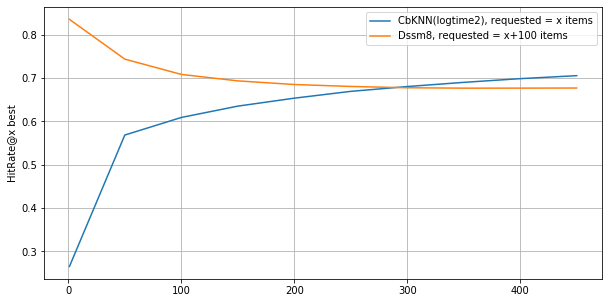

In [107]:
plt.figure(figsize=(10, 5))
plt.plot(x, ycm, label="CbKNN(logtime2), requested = x items")
plt.plot(x, ydm, label="Dssm8, requested = x+100 items")
plt.ylabel("HitRate@x best")
plt.legend()
plt.grid()
plt.show()

In [108]:
ycm = list()
ydm = list()
x = list()

for i in [1] + list(range(50, 500, 50)):
    x.append(i)
    ycm.append(get_score_custom(m, "test",  i, 100))
    ydm.append(get_score_custom(dm, "test",  i + 100, 100))
    print(i, "->", ycm[-1], ydm[-1])

1 -> 0.009760536398467433 0.5236877394636016
50 -> 0.39091475095785444 0.6339750957854408
100 -> 0.6092145593869731 0.7086350574712644
150 -> 0.7281465517241379 0.7617097701149426
200 -> 0.7974904214559386 0.8004166666666667
250 -> 0.8426484674329501 0.8292959770114943
300 -> 0.8731130268199233 0.8518534482758621
350 -> 0.8952538314176245 0.8704980842911877
400 -> 0.9113697318007663 0.8847988505747126
450 -> 0.9236494252873563 0.8974137931034483


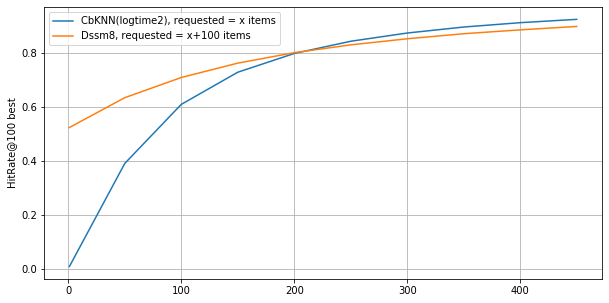

In [110]:
plt.figure(figsize=(10, 5))
plt.plot(x, ycm, label="CbKNN(logtime2), requested = x items")
plt.plot(x, ydm, label="Dssm8, requested = x+100 items")
plt.ylabel("HitRate@100 best")
plt.legend()
plt.grid()
plt.show()

In [115]:
ycm = list()
ydm = list()
x = list()

for i in [1] + list(range(50, 5050, 50)):
    x.append(i)
    ycm.append(get_score_custom(m, "test",  i, 1))
    ydm.append(get_score_custom(dm, "test",  i + 100, 1))
    print(i, "->", ycm[-1], ydm[-1])

1 -> 0.2653256704980843 0.835727969348659
50 -> 0.7605363984674329 0.8740421455938697
100 -> 0.8117816091954023 0.899904214559387
150 -> 0.8352490421455939 0.9118773946360154
200 -> 0.85727969348659 0.9209770114942529
250 -> 0.8716475095785441 0.928639846743295
300 -> 0.882183908045977 0.9377394636015326
350 -> 0.8912835249042146 0.9425287356321839
400 -> 0.9013409961685823 0.9501915708812261
450 -> 0.9090038314176245 0.9540229885057471
500 -> 0.9161877394636015 0.9573754789272031
550 -> 0.9219348659003831 0.9602490421455939
600 -> 0.9276819923371648 0.9621647509578544
650 -> 0.9305555555555556 0.9688697318007663
700 -> 0.9343869731800766 0.9712643678160919
750 -> 0.9367816091954023 0.9722222222222222
800 -> 0.9401340996168582 0.9746168582375478
850 -> 0.9454022988505747 0.9760536398467433
900 -> 0.9458812260536399 0.9774904214559387
950 -> 0.9501915708812261 0.9794061302681992
1000 -> 0.9525862068965517 0.9808429118773946
1050 -> 0.9568965517241379 0.9813218390804598
1100 -> 0.9578544

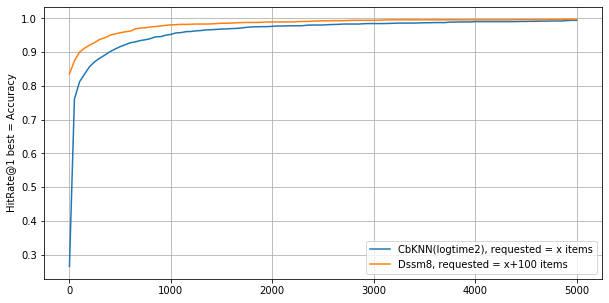

In [116]:
plt.figure(figsize=(10, 5))
plt.plot(x, ycm, label="CbKNN(logtime2), requested = x items")
plt.plot(x, ydm, label="Dssm8, requested = x+100 items")
plt.ylabel("HitRate@1 best = Accuracy")
plt.legend()
plt.grid()
plt.show()

<hr>

In [7]:
ctx = load(L, seed=17, det_attempts=DA).set_top_games_as_key()
pass

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088


In [20]:
N = 100

In [10]:
gc.collect()
ev([
    DssmKnn(ctx, 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[ 1.3099855e-03,  9.4640342e-04,  1.5870988e-04, ...,
         2.3911759e-04,  2.0618588e-04,  1.1041879e-03],
       [-6.8015151e-04,  3.9811939e-04,  6.8818463e-04, ...,
         3.9022134e-04, -2.0935535e-05,  7.5513555e-04],
       [-3.1250805e-04,  1.3498532e-03, -1.6690519e-03, ...,
         1.0845968e-03, -1.0286078e-04, -2.4271444e-04],
       ...,
       [-1.3376847e-03, -1.3134675e-03,  1.7126497e-03, ...,
         1.6389719e-03, -1.1626628e-03,  1.5400136e-03],
       [ 1.1873100e-03,  1.3876632e-04

In [13]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 101) dtype=float32, numpy=
array([[-0.00147542,  0.00164654,  0.00094504, ...,  0.00095823,
         0.0005148 ,  0.0013789 ],
       [-0.00040909, -0.00163493, -0.00132024, ..., -0.0006525 ,
         0.00095906,  0.00120513],
       [-0.00126614,  0.00104214, -0.00010766, ...,  0.00164741,
         0.00071401,  0.00052066],
       ...,
       [-0.00032644, -0.00100515,  0.00045999, ..., -0.00032491,
        -0.00064912,  0.00094154],
       [-0.00132566,  0.00167471,  0.00048872, ...,  0.00018932,
         0.00021268, -0.00130056],
       [-0.000

In [21]:
gc.collect()
ev([
    DssmKnn(ctx, 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[ 8.8083296e-05, -3.9741979e-04, -1.6371228e-03, ...,
         1.5156246e-03, -1.6283884e-03,  7.7666849e-04],
       [ 4.6822146e-04, -7.9344603e-04, -3.8897365e-04, ...,
         5.3110928e-04,  1.1113489e-03, -1.1881053e-03],
       [-1.6695252e-03,  6.0376048e-04, -1.3862967e-03, ...,
         1.7143479e-03,  7.5556547e-04, -8.3044200e-04],
       ...,
       [ 9.6369744e-04,  6.8692357e-04,  1.4632281e-03, ...,
        -4.4951306e-04,  4.7117696e-04, -3.4639746e-04],
       [-1.6748339e-04,  1.3709819e-03

In [22]:
gc.collect()
ev([
    DssmKnn(ctx, 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[-1.0149053e-03, -1.3837368e-03,  7.2454975e-04, ...,
         1.6374808e-03, -1.5277691e-03,  1.4562279e-03],
       [-1.4980402e-03, -1.1954772e-03,  1.0170534e-03, ...,
         1.5366769e-03,  3.2000989e-05,  1.2048632e-03],
       [-7.3641137e-04, -1.1221744e-03, -1.3788426e-03, ...,
        -1.1639963e-03, -1.5210867e-03,  1.4383760e-03],
       ...,
       [ 2.3445905e-04,  2.0153373e-05, -1.3630245e-03, ...,
        -7.3897047e-04,  5.7532504e-04, -9.5205347e-04],
       [ 9.0605795e-04, -1.2355899e-03

In [23]:
gc.collect()
ev([
    DssmKnn(ctx, 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[-1.4129202e-03, -7.7697705e-04, -1.4862367e-03, ...,
        -8.3383732e-04, -1.7250107e-03,  7.2711048e-04],
       [-1.6245475e-03, -2.8165296e-04, -1.4183699e-04, ...,
         1.5978068e-03,  3.9347858e-04,  1.3677243e-03],
       [-1.0923435e-03,  1.1012050e-03,  1.2270871e-03, ...,
         9.9552723e-05, -8.1396109e-04,  1.3274312e-03],
       ...,
       [-6.6037558e-04,  9.5166417e-04, -1.8817275e-04, ...,
         1.5017509e-03,  1.7216989e-03,  1.2884855e-03],
       [ 3.3370897e-04, -1.4985213e-03

In [14]:
N = 1000

In [15]:
gc.collect()
ev([
    DssmKnn(ctx, 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(1.0807164, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.40834975885929964 1.0807162504829866 4769
np.mean(results), mse, len(results) =  0.40479406130268203 4.0971001001934155 2088
0.40834975885929964 0.40479406130268203


In [16]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(0.42216286, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.496039001887188 0.422162868024669 4769
np.mean(results), mse, len(results) =  0.492418582375479 0.44902059845017595 2088
0.496039001887188 0.492418582375479


In [17]:
gc.collect()
ev([
    DssmKnn(ctx, 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(1.2194006, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3803837282449151 1.2194003766729133 4769
np.mean(results), mse, len(results) =  0.3769013409961686 4.261311384294862 2088
0.3803837282449151 0.3769013409961686


In [18]:
gc.collect()
ev([
    DssmKnn(ctx, 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(1.3214303, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3634682323338226 1.3214303049597298 4769
np.mean(results), mse, len(results) =  0.3615756704980843 4.160191452113321 2088
0.3634682323338226 0.3615756704980843


In [19]:
gc.collect()
ev([
    DssmKnn(ctx, 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(1.8342271, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3577961836863074 1.8342274979750026 4769
np.mean(results), mse, len(results) =  0.3546024904214559 5.652326399258021 2088
0.3577961836863074 0.3546024904214559
